In [1]:
import numpy
import itertools
import math
import gsd.hoomd
import os


#To get render function
import importlib
import viz_helpers
from viz_helpers import render

import Create_Lattices as cl

import Simulation_Helpers as sh


importlib.reload(sh)
importlib.reload(viz_helpers)
importlib.reload(cl)

<module 'Create_Lattices' from '/home/potto/Create_Lattices.py'>

Loaded existing lattice:
Simple_Lattices/Cubic/BoxLength_9.1/rho_0.40/lattice.gsd


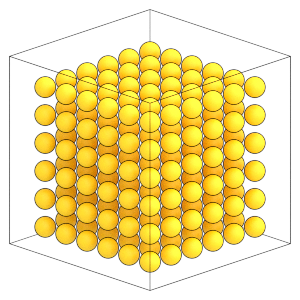

In [2]:
BoxLength = 9.1
rho = 0.4

frame = cl.make_lattice_frame(
    BoxLength=BoxLength,
    rho=rho,
    lattice_type="cubic",
)

render(frame)

Loaded existing lattice:
Simple_Lattices/FCC/BoxLength_9.1/rho_0.40/lattice.gsd


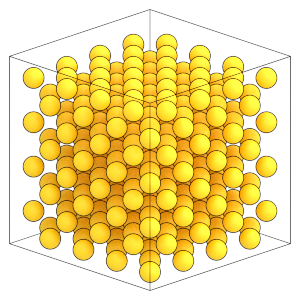

In [3]:
frame = cl.make_lattice_frame(
    BoxLength=BoxLength,
    rho=rho,
    lattice_type="fcc",
)

render(frame)

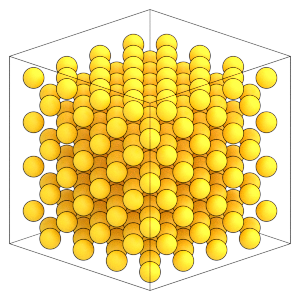

In [4]:
sim = sh.make_simulation(frame)

render(sim.state.get_snapshot())

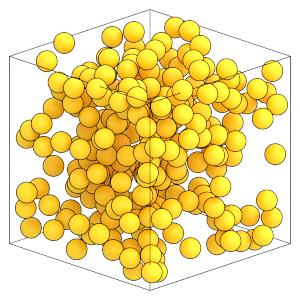

In [5]:
sim = sh.thermalize_and_randomize(sim, kT=1.5, nsteps=10_000)

render(sim.state.get_snapshot())

In [10]:
type(sim)

hoomd.simulation.Simulation

In [11]:
snap = sim.state.get_snapshot()

In [13]:
snap.particles.position[0:5]

array([[-0.48650569, -0.12081166, -4.4229808 ],
       [-0.35212271,  2.79361918,  0.44960172],
       [-2.34123331,  1.87466421, -1.3881895 ],
       [ 2.03831436, -4.3959955 ,  1.7539095 ],
       [ 2.2139778 ,  1.32740114,  2.22553076]])

In [14]:
import numpy as np

positions = snap.particles.position

# number of voxels per dimension
nbins = 10

# define box limits
L = sim.state.box.Lx  # assuming cubic
bounds = [[-L/2, L/2], [-L/2, L/2], [-L/2, L/2]]

hist, edges = np.histogramdd(
    positions,
    bins=nbins,
    range=bounds
)

In [15]:
print("Total particles:", hist.sum())
print("Expected:", sim.state.N_particles)

Total particles: 256.0
Expected: 256


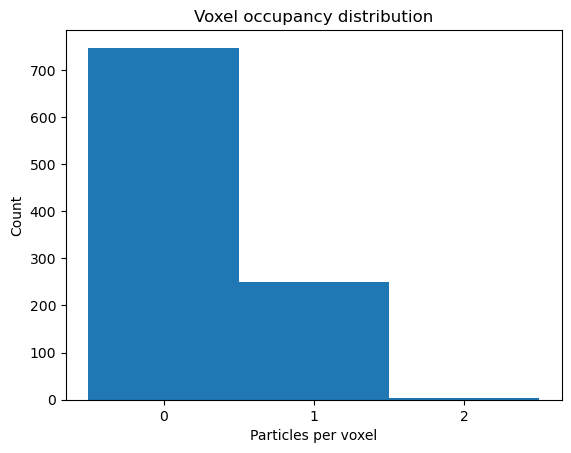

In [25]:
import numpy as np
import matplotlib.pyplot as plt

data = hist.ravel()

bins = np.arange(data.min() - 0.5, data.max() + 1.5, 1)

plt.hist(data, bins=bins)
plt.xticks(np.arange(data.min(), data.max() + 1))
plt.xlabel("Particles per voxel")
plt.ylabel("Count")
plt.title("Voxel occupancy distribution")

plt.show()

In [29]:
def plot_voxel_histogram(sim, nbins=10, use_density=False):
    """
    Compute voxel occupancy histogram and plot it with integer-centered bins.

    Parameters:
    - sim: HOOMD simulation
    - nbins: number of bins per dimension (voxel resolution)
    - use_density: if True, plots density instead of raw counts
    """

    # ============================================================
    # Extract positions
    # ============================================================
    snap = sim.state.get_snapshot()
    positions = snap.particles.position

    # Box size (assuming cubic)
    L = sim.state.box.Lx
    bounds = [[-L/2, L/2]] * 3

    # ============================================================
    # Compute voxel histogram
    # ============================================================
    hist, _ = np.histogramdd(
        positions,
        bins=nbins,
        range=bounds
    )

    # Convert to density if requested
    if use_density:
        voxel_volume = (L / nbins)**3
        hist = hist / voxel_volume

    # Flatten to 1D
    data = hist.ravel()

    # ============================================================
    # Build integer-centered bins
    # ============================================================
    min_val = int(np.floor(data.min()))
    max_val = int(np.ceil(data.max()))

    bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

    # ============================================================
    # Plot
    # ============================================================
    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=bins, edgecolor='black')

    plt.xticks(np.arange(min_val, max_val + 1))
    plt.xlabel("Particles per voxel" if not use_density else "Density per voxel")
    plt.ylabel("Count")
    plt.title(f"Voxel distribution (nbins={nbins})")

    plt.show()

    return hist

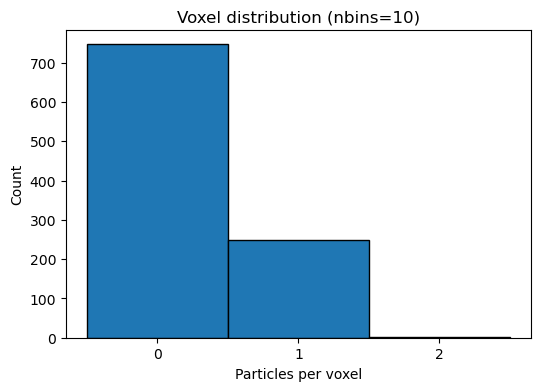

array([[[0., 0., 0., 1., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 1., 0., 0., 1., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 1., 0., 1., 0.],
        [0., 1., 0., 1., 0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 1., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 1., 0.],
        [1., 0., 0., 1., 1., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 1., 0., 0., 0.]],

       [[1., 1., 0., 1., 1., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [1., 0., 0., 1., 1., 0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0., 0., 1., 0., 0., 1.],
        [0., 0., 0., 1., 0., 0., 1., 0., 0., 0.],
        [0., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 2.],
        [1., 0., 1., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 1., 0., 0., 0., 0., 1.]

In [27]:
plot_voxel_histogram(sim, nbins=10)